                            OLS Regression Results                            
Dep. Variable:         log_firms_2022   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     1605.
Date:                Thu, 09 Oct 2025   Prob (F-statistic):               0.00
Time:                        11:21:05   Log-Likelihood:                -567.54
No. Observations:                2968   AIC:                             1241.
Df Residuals:                    2915   BIC:                             1559.
Df Model:                          52                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

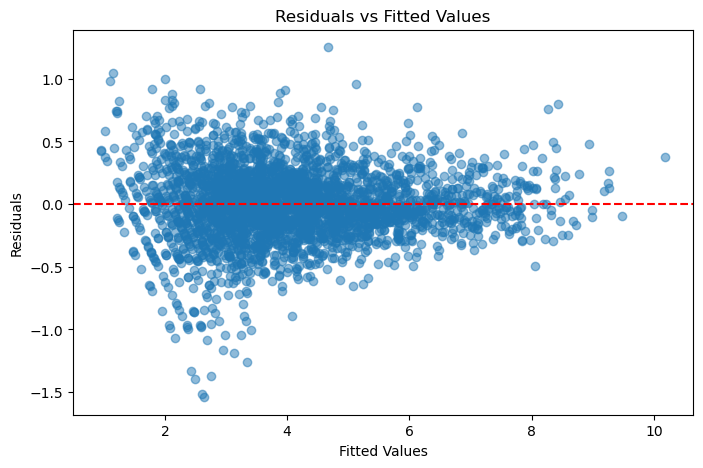

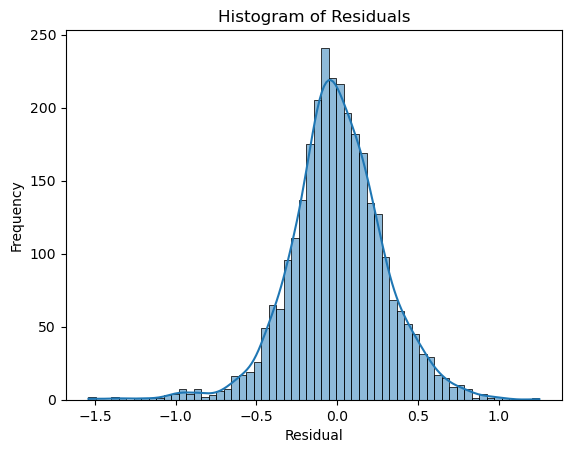

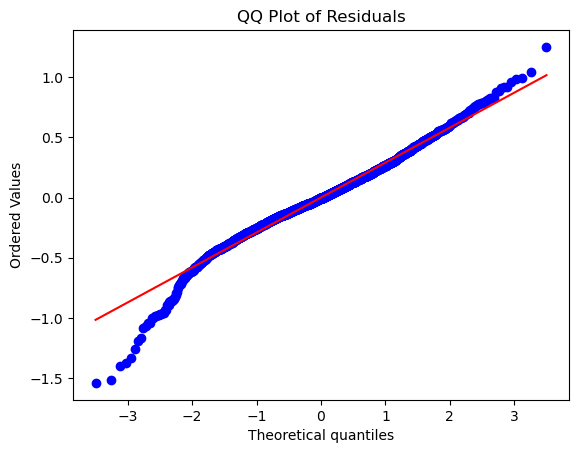

Breusch-Pagan Test Results:
{'LM Statistic': 278.60409851259476, 'LM-Test p-value': 9.891701047881034e-33, 'F-Statistic': 5.807215970487407, 'F-Test p-value': 9.828017136171335e-35}


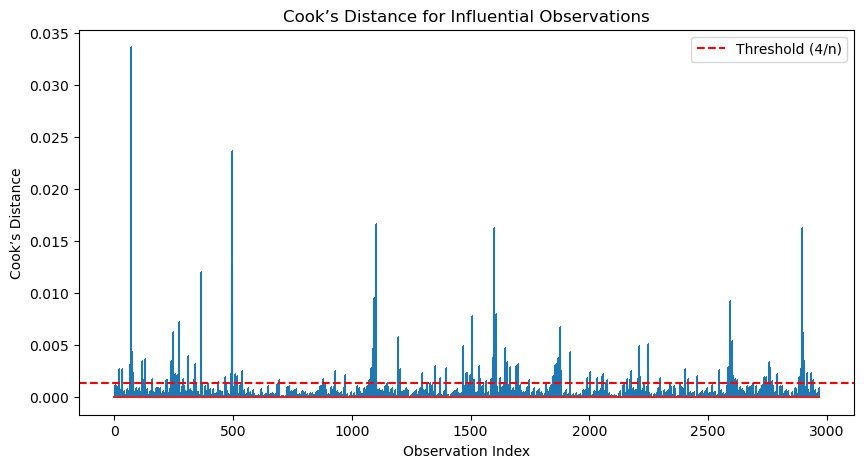

In [4]:




import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# Load the cleaned dataset
df = pd.read_csv("/Users/kimballweeks/Downloads/cleaned_data.csv")

# Rename for compatibility (IMPORTANT: these must match your CSV column names)
df = df.rename(columns={
    "pct_highschool_or_more (1990)": "pct_hs_1990",
    "Pop 2023": "pop_2023",
    "Established firms 2022": "firms_2022",
    "Established firms 1989": "firms_1989"
})

# Convert relevant columns to numeric
df['church_persistence_index'] = pd.to_numeric(df['church_persistence_index'], errors='coerce')
df['income_1989_real_2023'] = pd.to_numeric(df['income_1989_real_2023'], errors='coerce')
df['pct_hs_1990'] = pd.to_numeric(df['pct_hs_1990'], errors='coerce')
df['pop_2023'] = pd.to_numeric(df['pop_2023'], errors='coerce')
df['firms_2022'] = pd.to_numeric(df['firms_2022'], errors='coerce')
df['firms_1989'] = pd.to_numeric(df['firms_1989'], errors='coerce')

# Drop rows with missing values in these columns
df = df.dropna(subset=[
    'church_persistence_index',
    'income_1989_real_2023',
    'pct_hs_1990',
    'pop_2023',
    'firms_2022',
    'firms_1989'
])

# Drop rows where log would break
df = df[(df['firms_2022'] > 0) & (df['pop_2023'] > 0) & (df['firms_1989'] > 0)]

# Log-transform outcome and population + 1989 firms
df['log_firms_2022'] = np.log(df['firms_2022'])
df['log_pop_2023'] = np.log(df['pop_2023'])
df['log_firms_1989'] = np.log(df['firms_1989'])

# Standardize income and education
scaler = StandardScaler()
df[['income_1989_scaled', 'pct_hs_1990_scaled']] = scaler.fit_transform(
    df[['income_1989_real_2023', 'pct_hs_1990']]
)

# Run the regression
model = smf.ols(
    formula='log_firms_2022 ~ church_persistence_index + income_1989_scaled + pct_hs_1990_scaled + log_pop_2023 + log_firms_1989 + C(State)',
    data=df
).fit(cov_type='HC3')

# Output the summary
print(model.summary())


import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan

# 1. Add residuals and fitted values to the DataFrame
df['residuals'] = model.resid
df['fitted_values'] = model.fittedvalues

# 2. Plot residuals vs fitted values
plt.figure(figsize=(8, 5))
plt.scatter(df['fitted_values'], df['residuals'], alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

# 3. Histogram of residuals
sns.histplot(df['residuals'], kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

# 4. QQ plot to check for normality
stats.probplot(df['residuals'], dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()

# 5. Breusch-Pagan test for heteroskedasticity
bp_test = het_breuschpagan(model.resid, model.model.exog)
bp_labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("Breusch-Pagan Test Results:")
print(dict(zip(bp_labels, bp_test)))

# 6. Cook’s Distance to check for influential observations
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(4 / len(df), color='red', linestyle='--', label='Threshold (4/n)')
plt.xlabel("Observation Index")
plt.ylabel("Cook’s Distance")
plt.title("Cook’s Distance for Influential Observations")
plt.legend()
plt.show()
